# Analytic Solutions

In [1]:
%load_ext autoreload
%autoreload 2
from physics import soliton_library, kdv
from scattering import ScatteringData
from plot_utils import plot_field_visualization
from configuration import kdv_config
from sampling import sample_bulk
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import torch
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using {device} device.")


Using mps device.


In [ ]:
config = kdv_config
config.L = 10
config.T = 1
config.num_samp_eval = 256
L = config.L
T = config.T
config.kappas = [1.5 - 0.1 * i for i in range(10)]
config.x0s = [-L + i for i in range(10)]


input_eval = sample_bulk(config, resample=False, num_samp=config.num_samp_eval)
input_eval.requires_grad_(True)
sd = ScatteringData(config.kappas, config.x0s, R=None, use_tau=True)

t = input_eval[:, 0:1]
x = input_eval[:, 1:2]
u_analytic = sd.u(x, t)
print(sd.c0, sd.x0, config.x0s, config.kappas)
# S = soliton_library['scattering']
# u_analytic = S(input_eval, config)
# print(u_analytic)
u = u_analytic.reshape(config.num_samp_eval,config.num_samp_eval).detach().cpu().numpy()
m1 = plt.imshow(u, extent=[-L, L, 0, T],
                vmin=config.vmin, vmax=config.vmax,
                origin='lower', cmap='coolwarm', aspect='auto')
plt.colorbar(m1)


SyntaxError: did you forget parentheses around the comprehension target? (3204549465.py, line 8)

In [ ]:
# A = sd.A(x,t)
# fig, ax = plt.subplots(sd.Ns, sd.Ns, figsize=(8,8))
# for i in range(sd.Ns):
#     for j in range(sd.Ns):
#         A_reshape = A[:,i, j].reshape(config.num_samp_eval, config.num_samp_eval).detach().cpu()
#         im = ax[i][j].imshow(A_reshape,origin='lower', cmap='coolwarm', aspect='auto',extent=[-L, L, 0, T], norm=LogNorm())
#         plt.colorbar(im)
# #plt.show()


In [ ]:
results = kdv(u_analytic, input_eval)

### PDE Residuals

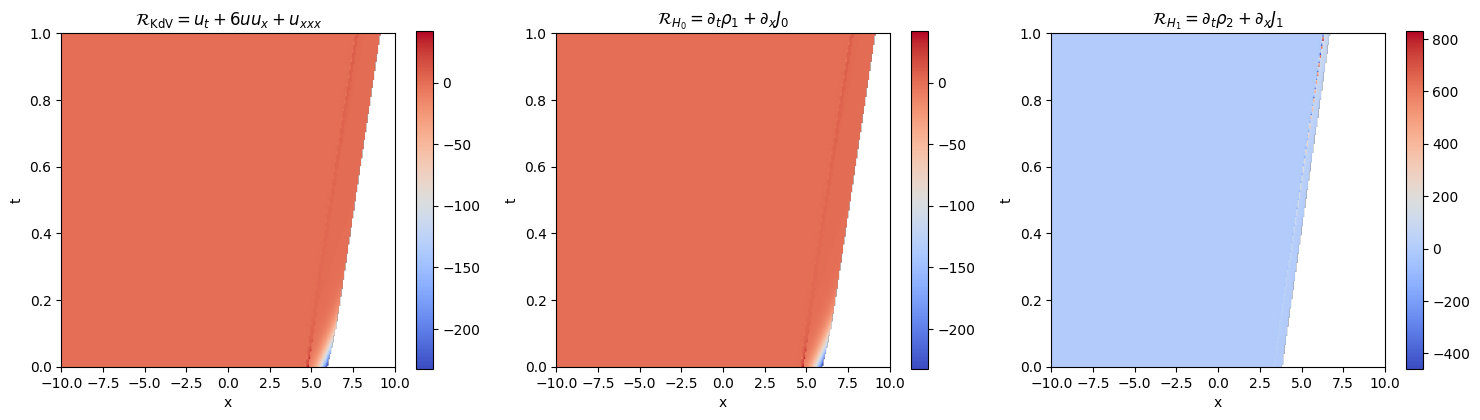

In [ ]:
plot_field_visualization(results, config, 'res')

### Field Derivatives

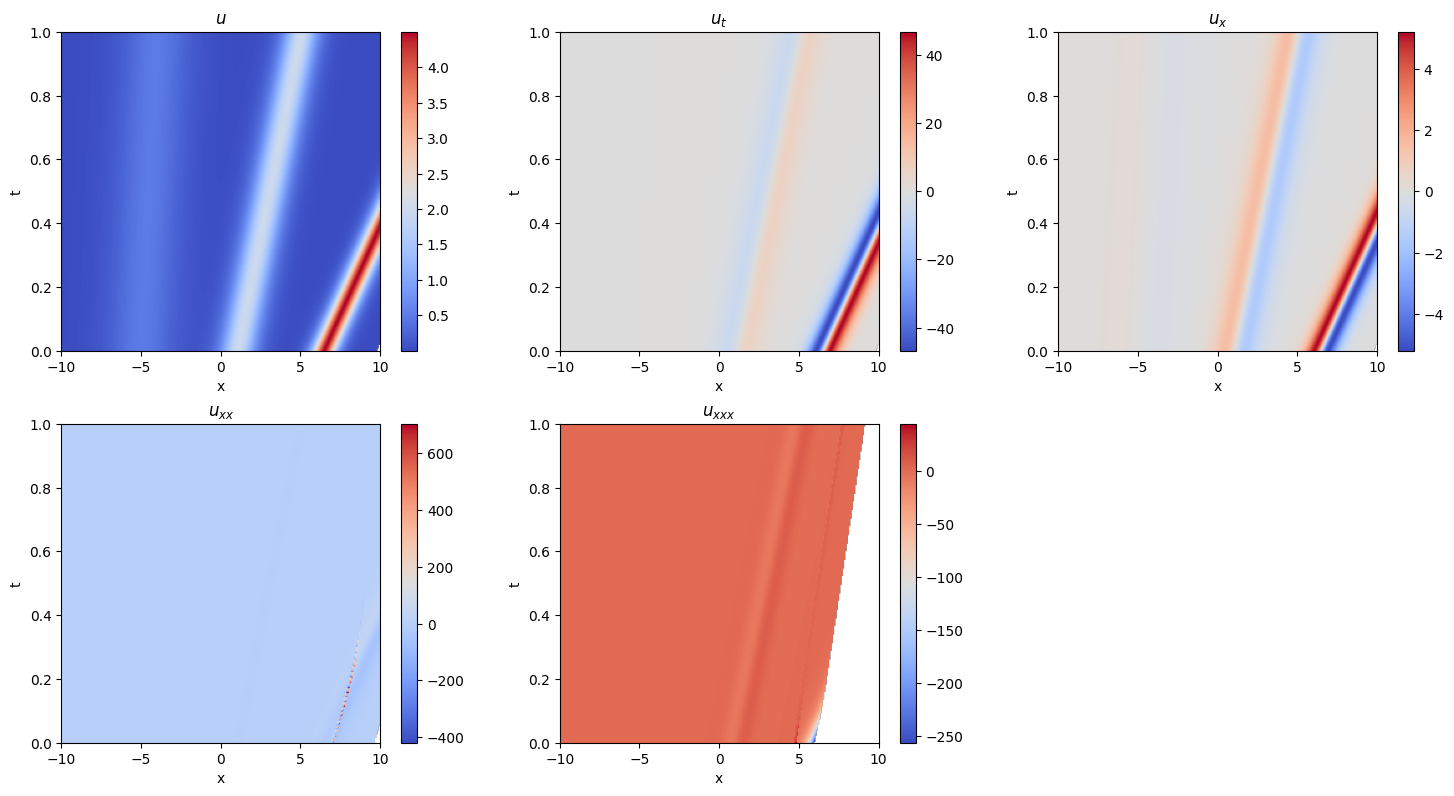

In [ ]:
plot_field_visualization(results, config, 'deriv')

### Integrals of Motion

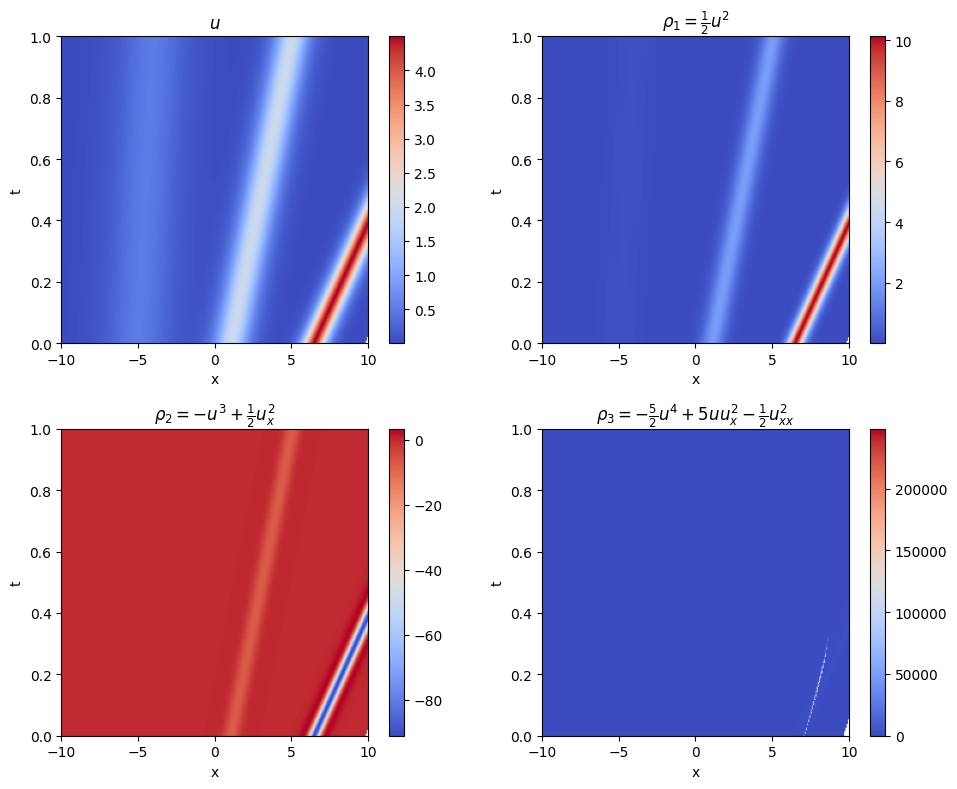

In [ ]:
plot_field_visualization(results, config, 'iom')

### Conservation Currents

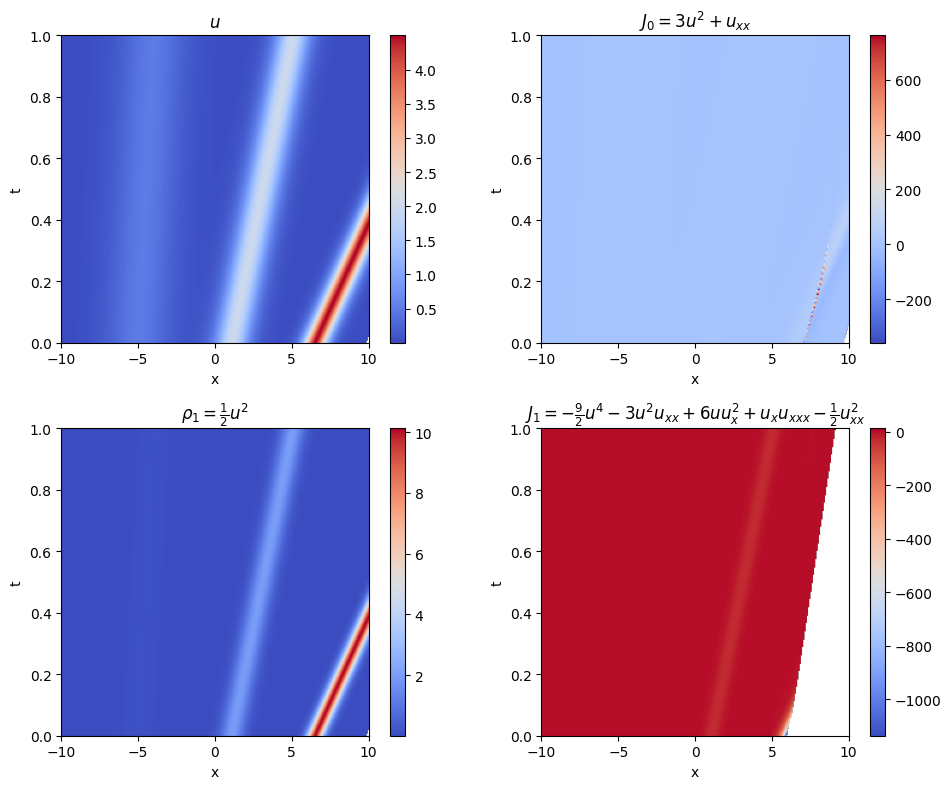

In [ ]:
plot_field_visualization(results, config, 'curr')